# Práctica: Predicción de supervivencia en el Titanic con Regresión Logística

## 1. Introducción

La clasificación es una de las tareas más importantes del aprendizaje automático supervisado: a partir de datos
etiquetados, se busca aprender una regla que permita asignar nuevas observaciones a una categoría conocida.
Dentro de los algoritmos de clasificación, la **Regresión Logística** es uno de los más utilizados porque,
además de predecir la clase, entrega una **probabilidad** interpretable y coeficientes que permiten entender
la relación entre cada variable y el resultado.

**Problemática:** el hundimiento del Titanic en 1912 es uno de los conjuntos de datos más conocidos en
ciencia de datos. A partir de la información de cada pasajero (clase del boleto, sexo, edad, número de
familiares a bordo, tarifa pagada, puerto de embarque) se desea predecir si **sobrevivió o no** al naufragio.
Es un problema binario, con datos reales, fácil de entender y sin necesidad de conocimientos técnicos
especializados de ningún dominio particular.

**Objetivo:** construir un modelo de Regresión Logística capaz de predecir si un pasajero **sobrevivió (1)**
o **no sobrevivió (0)** a partir de sus características, evaluando su desempeño con métricas de clasificación
y analizando qué variables influyeron más en la probabilidad de supervivencia.

**Justificación del algoritmo:** la Regresión Logística es adecuada para este problema porque:
- La variable objetivo es **binaria** (sobrevivió / no sobrevivió).
- Entrega una **probabilidad** de supervivencia para cada pasajero, no solo una etiqueta.
- Sus coeficientes son **interpretables**: permiten responder preguntas como "¿viajar en primera clase
  aumentaba la probabilidad de sobrevivir?" o "¿el sexo del pasajero influyó en el resultado?".
- Es un algoritmo simple, rápido de entrenar y una excelente línea base (*baseline*) para problemas de
  clasificación binaria.

## 2. Explicación del algoritmo: funcionamiento y lógica

**¿Qué es la Regresión Logística?**
Es un algoritmo de **aprendizaje supervisado** utilizado para problemas de **clasificación** (no de regresión
numérica, a pesar del nombre). Es supervisado porque durante el entrenamiento el modelo recibe pares
$(X_i, y_i)$: las variables predictoras **y** la etiqueta/clase correcta, y ajusta sus parámetros para minimizar
el error entre lo predicho y lo real.

**La función sigmoide.**
La Regresión Logística calcula primero una combinación lineal de las variables de entrada, igual que una
regresión lineal:

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

Ese valor $z$ puede tomar cualquier número real, por lo que no sirve directamente como probabilidad. Para
convertirlo en un valor entre 0 y 1, se aplica la **función sigmoide (logística)**:

$$P(y=1 \mid X) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

La curva sigmoide tiene forma de "S": para valores de $z$ muy negativos, $\sigma(z) \to 0$; para valores muy
positivos, $\sigma(z) \to 1$; y en $z=0$, $\sigma(z)=0.5$. Ese valor $P(y=1\mid X)$ es la probabilidad estimada
de que la observación pertenezca a la clase positiva (en este caso, "sobrevivió"), y se convierte en una
predicción de clase aplicando un umbral (normalmente 0.5).

**Binaria vs. multiclase.**
En su forma básica, la Regresión Logística es **binaria** (dos clases, como en este caso: sobrevivió/no
sobrevivió). Para más de dos clases existen extensiones como **One-vs-Rest (OvR)**, que entrena un clasificador
binario por cada clase, o la **regresión logística multinomial (softmax)**, que generaliza la sigmoide para
varias clases a la vez. `sklearn.linear_model.LogisticRegression` soporta ambos casos automáticamente según el
número de clases de `y`.

**Características del algoritmo.**
- Es **interpretable**: cada coeficiente $\beta_i$ indica cuánto cambia el *log-odds* (logaritmo de la razón de
  momios) de la clase positiva al aumentar en una unidad la variable $x_i$, manteniendo las demás constantes.
- Se implementa fácilmente con `sklearn.linear_model.LogisticRegression`, que permite ajustar regularización,
  el algoritmo de optimización (`solver`) y otros hiperparámetros.
- Es computacionalmente eficiente y funciona bien como línea base incluso con pocos datos.

**Limitaciones.**
- Supone que existe una relación **lineal entre las variables predictoras y el logit** (el log-odds), por lo
  que fronteras de decisión muy curvas o no lineales pueden requerir transformar variables o usar otro
  algoritmo.
- Es sensible a la **multicolinealidad** (variables predictoras muy correlacionadas entre sí), lo que puede
  hacer inestables a los coeficientes.
- Requiere variables **numéricas** (las categóricas deben codificarse previamente).
- Su desempeño puede ser bajo frente a fronteras de decisión muy complejas, donde modelos como árboles,
  *random forest* o redes neuronales suelen superarla.

**Áreas de aplicación real.**
- Diagnóstico médico (predicción de riesgo de enfermedades).
- Detección de fraude en transacciones financieras.
- Marketing: predicción de abandono de clientes (*churn*).
- Scoring crediticio: aprobación o rechazo de créditos.
- Filtros de correo no deseado (spam).
- Análisis histórico/social, como estimar qué factores influyeron en la supervivencia de un evento (este caso).

## 3. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

## 4. Obtención de datos y carga

**Fuente de los datos:** se utiliza el dataset **Titanic - Machine Learning from Disaster**, uno de los
conjuntos de datos reales más conocidos en ciencia de datos (publicado originalmente en
[Kaggle](https://www.kaggle.com/c/titanic)). Contiene información de 891 pasajeros del Titanic: clase del
boleto, sexo, edad, familiares a bordo, tarifa pagada, puerto de embarque y si sobrevivieron o no. Se carga
directamente con `pandas.read_csv` desde una copia pública del dataset.

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
dfTitanic = pd.read_csv(url)

In [3]:
dfTitanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Exploración del conjunto de datos

In [4]:
dfTitanic.shape

(891, 15)

In [5]:
dfTitanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [6]:
dfTitanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [7]:
dfTitanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


El dataset original trae varias columnas redundantes o con demasiados valores nulos para ser útiles
(por ejemplo, `deck` tiene más de 600 valores nulos, y `class`, `who`, `adult_male`, `embark_town`, `alive` y
`alone` son variantes o duplicados de columnas que ya se usarán). Para esta práctica se seleccionan las
variables más relevantes y con buena calidad de datos:

- `pclass`: clase del boleto (1 = primera, 2 = segunda, 3 = tercera).
- `sex`: sexo del pasajero.
- `age`: edad en años.
- `sibsp`: número de hermanos/cónyuges a bordo.
- `parch`: número de padres/hijos a bordo.
- `fare`: tarifa pagada por el boleto.
- `embarked`: puerto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton).
- `survived`: variable objetivo (0 = no sobrevivió, 1 = sobrevivió).

In [8]:
columnas_utiles = ["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
dfTitanic = dfTitanic[columnas_utiles]
dfTitanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 5. Preprocesamiento

Antes de entrenar el modelo se revisan tres aspectos clave: valores nulos, variables categóricas y balance de
clases.

In [9]:
# Revisión de valores nulos
dfTitanic.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

Existen valores nulos en `age` (177 casos) y en `embarked` (2 casos). Estos se tratarán **después** de
dividir los datos en entrenamiento y prueba, calculando la mediana/moda únicamente con el conjunto de
entrenamiento, para evitar fuga de información (más adelante se explica este paso en detalle).

**Balance de clases de la variable objetivo:**

In [10]:
dfTitanic["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [11]:
dfTitanic["survived"].value_counts(normalize=True) * 100

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

Las clases están moderadamente desbalanceadas (aprox. 62% no sobrevivió / 38% sobrevivió), por lo que
más adelante se usará `stratify=y` al dividir los datos en entrenamiento y prueba, para conservar esta
proporción en ambos conjuntos.

/tmp/ipykernel_262956/2426126228.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dfTitanic, x="survived", palette="Set2")


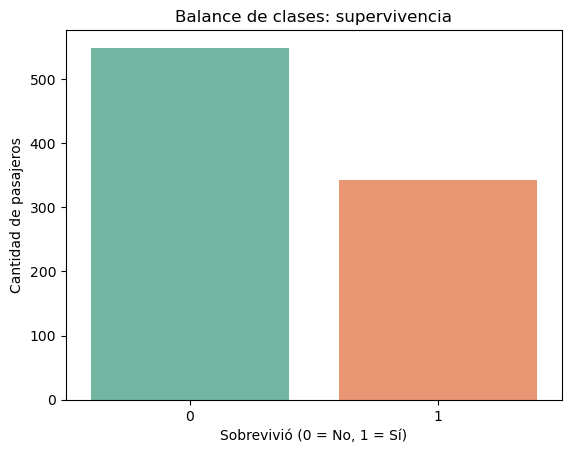

In [12]:
sns.countplot(data=dfTitanic, x="survived", palette="Set2")
plt.title("Balance de clases: supervivencia")
plt.xlabel("Sobrevivió (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de pasajeros")
plt.show()

**Codificación de variables categóricas:** `sex` y `embarked` son variables categóricas de tipo texto y
deben convertirse a valores numéricos antes de entrenar el modelo:
- `sex` tiene solo dos categorías (`male`/`female`), por lo que se codifica como una sola columna binaria
  (0/1) con `map`.
- `embarked` tiene tres categorías sin orden natural (`C`, `Q`, `S`), por lo que se codifica con
  **one-hot encoding** (`pd.get_dummies`), usando `drop_first=True` para evitar la multicolinealidad perfecta
  entre las columnas generadas.

## 6. Identificar variables predictoras y variable objetivo

In [13]:
# Variable objetivo
y = dfTitanic["survived"]

# Variables predictoras (antes de codificar)
X_crudo = dfTitanic.drop(columns=["survived"])

In [14]:
print("Variables predictoras (antes de codificar):")
print(X_crudo.columns.tolist())
print("Variable objetivo:", y.name)

Variables predictoras (antes de codificar):
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Variable objetivo: survived


## 7. División de los datos: entrenamiento y prueba

Se utiliza una división **80% entrenamiento / 20% prueba**, un estándar razonable que deja suficientes datos
para entrenar el modelo y un conjunto de prueba representativo para evaluarlo. Se fija `random_state=42` para
que la división sea **reproducible** (siempre se obtienen los mismos conjuntos al volver a ejecutar el
notebook), y se usa `stratify=y` porque, como se vio en el punto anterior, las clases no están perfectamente
balanceadas: esto asegura que la proporción de sobrevivientes se mantenga tanto en `train` como en `test`.

La división se hace **antes** de imputar valores nulos, codificar variables y escalar, precisamente para poder
ajustar esos pasos únicamente con el conjunto de entrenamiento y evitar fuga de información (*data leakage*).

In [15]:
X_train_crudo, X_test_crudo, y_train, y_test = train_test_split(
    X_crudo, y, test_size=0.20, random_state=42, stratify=y
)

In [16]:
print("X_train", X_train_crudo.shape)
print("X_test", X_test_crudo.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (712, 7)
X_test (179, 7)
y_train (712,)
y_test (179,)


**Prevención de fuga de información (data leakage):** todos los estadísticos necesarios para el
preprocesamiento (mediana de `age`, moda de `embarked`, media/desviación estándar para el escalado) se
calculan **únicamente con `X_train_crudo`**. El conjunto de prueba solo se **transforma** con esos valores ya
calculados, sin volver a ajustarlos. Así el modelo nunca "ve" información del conjunto de prueba durante el
entrenamiento.

## Tratamiento de nulos y codificación de variables categóricas

In [17]:
# Copiamos los conjuntos para no modificar los originales
X_train = X_train_crudo.copy()
X_test = X_test_crudo.copy()

# --- Imputación de nulos (ajustada solo con X_train) ---
mediana_edad = X_train["age"].median()
moda_embarque = X_train["embarked"].mode()[0]

print("Mediana de edad (train):", mediana_edad)
print("Moda de puerto de embarque (train):", moda_embarque)

X_train["age"] = X_train["age"].fillna(mediana_edad)
X_test["age"] = X_test["age"].fillna(mediana_edad)

X_train["embarked"] = X_train["embarked"].fillna(moda_embarque)
X_test["embarked"] = X_test["embarked"].fillna(moda_embarque)

Mediana de edad (train): 28.5
Moda de puerto de embarque (train): S


In [18]:
# --- Codificación de variables categóricas ---
X_train["sex"] = X_train["sex"].map({"male": 1, "female": 0})
X_test["sex"] = X_test["sex"].map({"male": 1, "female": 0})

X_train = pd.get_dummies(X_train, columns=["embarked"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["embarked"], drop_first=True)

# Alineamos columnas por si alguna categoría de 'embarked' no aparece en test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train.head()

,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
692,3,1,28.5,0,0,56.4958,False,True
481,2,1,28.5,0,0,0.0000,False,True
527,1,1,28.5,0,0,221.7792,False,True
855,3,0,18.0,0,1,9.3500,False,True
801,2,0,31.0,1,1,26.2500,False,True


In [19]:
print("Valores nulos en X_train:")
print(X_train.isnull().sum())

Valores nulos en X_train:
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked_Q    0
embarked_S    0
dtype: int64


## Escalado de variables

Se utiliza `StandardScaler` para estandarizar las variables (media 0, desviación estándar 1). Esto es
especialmente recomendable en Regresión Logística porque:
- El algoritmo de optimización (`solver`) usa métodos basados en gradiente que **convergen más rápido y de
  forma más estable** cuando las variables están en escalas comparables.
- Las variables de este dataset tienen **rangos muy distintos** (por ejemplo, `fare` puede superar 500,
  mientras que `sex` o las columnas de `embarked` son 0/1); sin escalar, las variables de mayor magnitud
  dominarían el ajuste del modelo.
- Cuando se aplica regularización (parámetro `C`), esta penaliza los coeficientes de forma uniforme solo si
  las variables están en la misma escala.

In [20]:
scaler = StandardScaler()

# Ajustamos el scaler SOLO con el conjunto de entrenamiento
X_train_escalado = scaler.fit_transform(X_train)
# El conjunto de prueba solo se transforma (no se vuelve a ajustar)
X_test_escalado = scaler.transform(X_test)

In [21]:
print("Sin escalar")
print(X_train.head())
print("Escalado")
print(X_train_escalado[:5])

Sin escalar
     pclass  sex   age  sibsp  parch      fare  embarked_Q  embarked_S
692       3    1  28.5      0      0   56.4958       False        True
481       2    1  28.5      0      0    0.0000       False        True
527       1    1  28.5      0      0  221.7792       False        True
855       3    0  18.0      0      1    9.3500       False        True
801       2    0  31.0      1      1   26.2500       False        True
Escalado
[[ 0.82956755  0.74242727 -0.08113533 -0.46508428 -0.46618317  0.5138115
  -0.28933346  0.61197825]
 [-0.37094484  0.74242727 -0.08113533 -0.46508428 -0.46618317 -0.66256323
  -0.28933346  0.61197825]
 [-1.57145722  0.74242727 -0.08113533 -0.46508428 -0.46618317  3.95539858
  -0.28933346  0.61197825]
 [ 0.82956755 -1.34693328 -0.88782719 -0.46508428  0.72778236 -0.46787435
  -0.28933346  0.61197825]
 [-0.37094484 -1.34693328  0.11093416  0.47833454  0.72778236 -0.11597681
  -0.28933346  0.61197825]]


## 8. Implementación del modelo: Regresión Logística

**Parámetros relevantes de `LogisticRegression`:**
- `penalty='l2'`: tipo de regularización aplicada a los coeficientes (por defecto, L2 o "ridge"), ayuda a
  evitar sobreajuste penalizando coeficientes muy grandes.
- `C=1.0`: inverso de la fuerza de regularización; valores más **pequeños** de `C` aplican una regularización
  **más fuerte** (coeficientes más pequeños), valores más **grandes** regularizan menos.
- `solver='lbfgs'`: algoritmo de optimización utilizado para ajustar los coeficientes (funciona bien con
  `penalty='l2'` y datasets de tamaño pequeño/mediano como este).
- `max_iter=1000`: número máximo de iteraciones que el `solver` puede realizar hasta converger.
- `random_state=42`: semilla para asegurar resultados reproducibles.

In [22]:
modelo = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

In [23]:
modelo.fit(X_train_escalado, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Importancia de las variables (coeficientes del modelo)

Los coeficientes de la Regresión Logística (`model.coef_`) indican el efecto de cada variable (ya escalada)
sobre el *log-odds* de sobrevivir. Un coeficiente positivo aumenta la probabilidad de sobrevivir; uno negativo
la disminuye. Para visualizar qué variables tienen mayor peso en la predicción, se grafica el **valor
absoluto** de los coeficientes.

In [24]:
coeficientes = pd.DataFrame({
    "variable": X_train.columns,
    "coeficiente": modelo.coef_[0]
})
coeficientes["coeficiente_abs"] = coeficientes["coeficiente"].abs()
coeficientes = coeficientes.sort_values("coeficiente_abs", ascending=False)
coeficientes

,variable,coeficiente,coeficiente_abs
1,sex,-1.269284,1.269284
0,pclass,-0.929413,0.929413
2,age,-0.505370,0.505370
3,sibsp,-0.263187,0.263187
7,embarked_S,-0.172681,0.172681
5,fare,0.099337,0.099337
6,embarked_Q,0.082915,0.082915
4,parch,-0.068072,0.068072


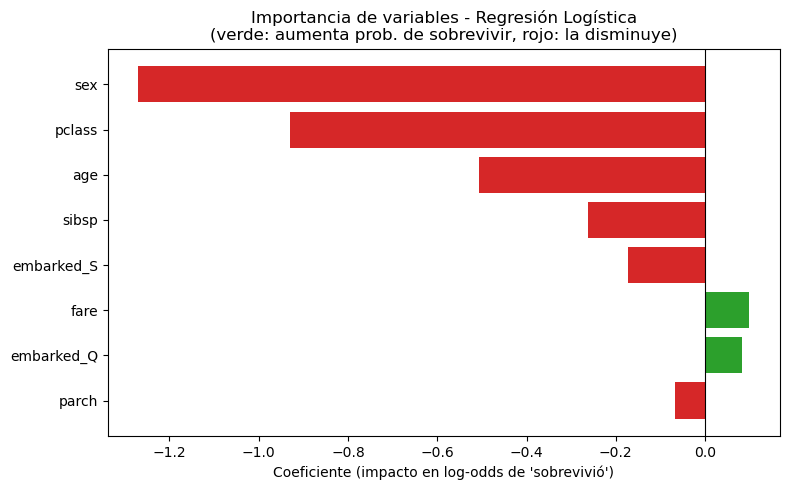

In [25]:
orden = coeficientes.sort_values("coeficiente_abs")

colores = ["#d62728" if c < 0 else "#2ca02c" for c in orden["coeficiente"]]

plt.figure(figsize=(8, 5))
plt.barh(orden["variable"], orden["coeficiente"], color=colores)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente (impacto en log-odds de 'sobrevivió')")
plt.title("Importancia de variables - Regresión Logística\n(verde: aumenta prob. de sobrevivir, rojo: la disminuye)")
plt.tight_layout()
plt.show()

**Interpretación:** se espera que `sex` (codificado como 1 = hombre) tenga uno de los coeficientes
**negativos** más grandes: ser hombre disminuye fuertemente la probabilidad de sobrevivir, reflejando el
protocolo histórico de dar prioridad a mujeres y niños en los botes salvavidas. `pclass` también suele tener
coeficiente **negativo** importante: a mayor número de clase (viajar en 2da o 3ra clase en vez de 1ra), menor
la probabilidad de sobrevivir, posiblemente por la ubicación de los camarotes respecto a los botes salvavidas.
Variables como `fare` (tarifa pagada, relacionada con la clase) suelen tener coeficiente **positivo**. Estas
relaciones deben interpretarse a la luz de los datos obtenidos en la celda anterior.

## Predicciones sobre el conjunto de prueba

In [26]:
prediccion = modelo.predict(X_test_escalado)
probabilidad = modelo.predict_proba(X_test_escalado)

In [27]:
print(prediccion[:10])

[0 0 0 0 1 0 1 0 0 0]


In [28]:
comparacion = pd.DataFrame({
    "sobrevivio real": y_test.map({0: "no", 1: "si"}).values,
    "sobrevivio predicho": pd.Series(prediccion).map({0: "no", 1: "si"}).values,
    "prob. sobrevivir": probabilidad[:, 1].round(3)
})
comparacion.head(15)

,sobrevivio real,sobrevivio predicho,prob. sobrevivir
0,no,no,0.066
1,no,no,0.047
2,si,no,0.152
3,no,no,0.035
4,si,si,0.682
5,si,no,0.445
6,si,si,0.756
7,no,no,0.326
8,no,no,0.344
9,no,no,0.159


## 9. Evaluación del modelo

Al tratarse de un problema de **clasificación**, se calculan e interpretan las métricas correspondientes:
exactitud (*accuracy*), precisión, *recall*, F1-score, matriz de confusión y curva ROC/AUC.

In [29]:
accuracy = accuracy_score(y_test, prediccion)
print(f"accuracy/exactitud: {accuracy:.4f}")

accuracy/exactitud: 0.8045


In [30]:
# Matriz de confusión
cm = confusion_matrix(y_test, prediccion)
cm_df = pd.DataFrame(
    cm,
    index=["real: no sobrevivio", "real: sobrevivio"],
    columns=["pred: no sobrevivio", "pred: sobrevivio"]
)
cm_df

,pred: no sobrevivio,pred: sobrevivio
real: no sobrevivio,98,12
real: sobrevivio,23,46


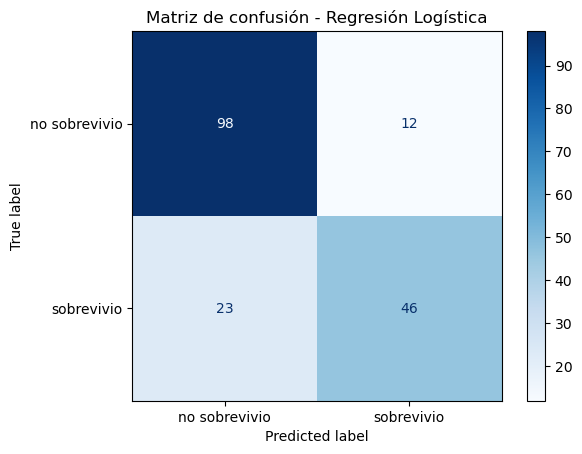

In [31]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no sobrevivio", "sobrevivio"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

## Classification report
Proporciona métricas que permiten evaluar el desempeño de cada clase: precision, recall, f1-score, support

In [32]:
print(classification_report(y_test, prediccion, target_names=["no sobrevivio", "sobrevivio"]))

               precision    recall  f1-score   support

no sobrevivio       0.81      0.89      0.85       110
   sobrevivio       0.79      0.67      0.72        69

     accuracy                           0.80       179
    macro avg       0.80      0.78      0.79       179
 weighted avg       0.80      0.80      0.80       179



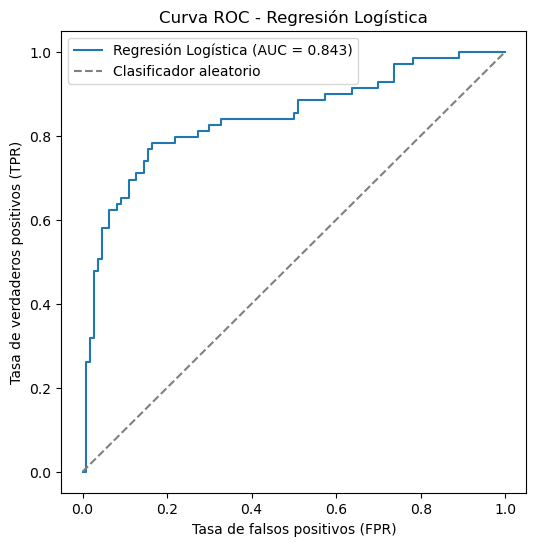

AUC: 0.8428


In [33]:
# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, probabilidad[:, 1])
auc = roc_auc_score(y_test, probabilidad[:, 1])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Regresión Logística (AUC = {auc:.3f})", color="#1f77b4")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.show()

print(f"AUC: {auc:.4f}")

**Interpretación de las métricas en el contexto del problema:**
- **Accuracy:** proporción total de pasajeros clasificados correctamente (sobrevivió/no sobrevivió) sobre el
  total evaluado.
- **Precision (clase "sobrevivió"):** de todos los pasajeros que el modelo predijo como sobrevivientes, qué
  porcentaje realmente sobrevivió. Una precisión baja implicaría muchos **falsos positivos** (predecir que un
  pasajero sobrevivió cuando en realidad no lo hizo).
- **Recall (clase "sobrevivió"):** de todos los pasajeros que realmente sobrevivieron, qué porcentaje detectó
  el modelo. Un **falso negativo** aquí sería predecir que un sobreviviente real no sobrevivió.
- **F1-score:** balance entre precisión y recall, útil para resumir el desempeño en una sola métrica.
- **Matriz de confusión:** permite ver exactamente cuántos falsos positivos y falsos negativos comete el
  modelo, no solo un promedio.
- **Curva ROC / AUC:** mide la capacidad del modelo para separar a los sobrevivientes de los no sobrevivientes
  en todos los posibles umbrales de decisión, independientemente del umbral de 0.5 usado por defecto. Un AUC
  cercano a 1 indica una muy buena separación entre ambas clases.

## 10. Implementación con datos nuevos

Se simulan dos pasajeros nuevos (que no forman parte de `train` ni de `test`), con el mismo número y orden de
columnas que `X`. Se aplica el **mismo preprocesamiento** ya ajustado (imputación con los valores del
entrenamiento, misma codificación y `scaler.transform` sin `fit`) y se obtiene la predicción del modelo junto
con su probabilidad.

In [34]:
# Pasajero 1: mujer, primera clase, adulta joven, viaja sola, tarifa alta, embarcó en Cherbourg
# Pasajero 2: hombre, tercera clase, adulto, viaja solo, tarifa baja, embarcó en Southampton
pasajeros_nuevos = pd.DataFrame([
    {"pclass": 1, "sex": "female", "age": 28, "sibsp": 0, "parch": 0, "fare": 80.0, "embarked": "C"},
    {"pclass": 3, "sex": "male",   "age": 30, "sibsp": 0, "parch": 0, "fare": 8.0,  "embarked": "S"},
], index=["pasajero_1", "pasajero_2"])

pasajeros_nuevos

,pclass,sex,age,sibsp,parch,fare,embarked
pasajero_1,1,female,28,0,0,80.0,C
pasajero_2,3,male,30,0,0,8.0,S


In [35]:
# Aplicamos el MISMO preprocesamiento que a train/test (sin volver a ajustar nada)
pasajeros_prep = pasajeros_nuevos.copy()

pasajeros_prep["age"] = pasajeros_prep["age"].fillna(mediana_edad)
pasajeros_prep["embarked"] = pasajeros_prep["embarked"].fillna(moda_embarque)

pasajeros_prep["sex"] = pasajeros_prep["sex"].map({"male": 1, "female": 0})
pasajeros_prep = pd.get_dummies(pasajeros_prep, columns=["embarked"], drop_first=True)

# Alineamos columnas exactamente con las de X_train (mismo orden, mismas categorías)
pasajeros_prep = pasajeros_prep.reindex(columns=X_train.columns, fill_value=0)

# Solo transform, el scaler ya fue ajustado con X_train
pasajeros_escalado = scaler.transform(pasajeros_prep)

prediccion_nueva = modelo.predict(pasajeros_escalado)
probabilidad_nueva = modelo.predict_proba(pasajeros_escalado)

In [36]:
for nombre, pred, prob in zip(pasajeros_nuevos.index, prediccion_nueva, probabilidad_nueva):
    etiqueta = "sobrevivio" if pred == 1 else "no sobrevivio"
    print(f"{nombre}: el modelo predice '{etiqueta}' "
          f"(prob. no sobrevivir = {prob[0]:.2%}, prob. sobrevivir = {prob[1]:.2%})")

pasajero_1: el modelo predice 'sobrevivio' (prob. no sobrevivir = 4.37%, prob. sobrevivir = 95.63%)
pasajero_2: el modelo predice 'no sobrevivio' (prob. no sobrevivir = 91.78%, prob. sobrevivir = 8.22%)


**Explicación del resultado:** para `pasajero_1` (mujer, primera clase, tarifa alta), el modelo predice
una probabilidad alta de sobrevivir, consistente con el patrón histórico de que mujeres y pasajeros de primera
clase tuvieron mayores tasas de supervivencia. Para `pasajero_2` (hombre, tercera clase, tarifa baja), el
modelo predice una probabilidad baja de sobrevivir, reflejando que los hombres de tercera clase fueron el
grupo con menor tasa de supervivencia en el naufragio real. Esto confirma que el modelo capturó relaciones
consistentes con el contexto histórico del problema.

## 11. Conclusiones

- **Desempeño del modelo:** la Regresión Logística obtuvo un desempeño bueno en este problema (ver accuracy y
  AUC en las celdas de evaluación), mostrando que variables simples como sexo, clase del boleto, edad y
  familiares a bordo son suficientemente informativas para predecir la supervivencia con una relación
  aproximadamente lineal respecto al logit.
- **Utilidad práctica:** aunque este es un caso histórico y no una aplicación en producción, el mismo enfoque
  (identificar qué variables se asocian más fuertemente con un resultado binario) es directamente aplicable a
  problemas reales como abandono de clientes, aprobación de créditos o detección de fraude.
- **Limitaciones encontradas:** el dataset es relativamente pequeño (891 registros) y algunas variables tienen
  valores nulos que debieron imputarse (`age`, `embarked`), lo que introduce cierta incertidumbre. Además,
  variables como `pclass` y `fare` están correlacionadas entre sí, lo que puede generar cierta
  multicolinealidad y hacer menos estables los coeficientes individuales.
- **Mejoras futuras:**
  - Probar distintos valores de regularización (`C`) mediante validación cruzada (`GridSearchCV`).
  - Ajustar el **umbral de decisión** (no usar siempre 0.5) según el objetivo del análisis.
  - Crear nuevas variables (ingeniería de variables), por ejemplo el tamaño total de la familia a bordo
    (`sibsp + parch`) o extraer el título del nombre del pasajero (Mr., Mrs., Miss, etc.).
  - Comparar el desempeño contra otros algoritmos (Random Forest, SVM, KNN) para verificar si una frontera de
    decisión no lineal mejora los resultados.
  - Probar técnicas de balanceo de clases (por ejemplo, SMOTE) si se buscara mejorar específicamente la
    detección de la clase minoritaria.
- **Aprendizaje técnico obtenido:** esta práctica permitió aplicar el flujo completo de un proyecto de
  Machine Learning supervisado: desde el preprocesamiento (nulos, codificación de variables categóricas,
  escalado y balance de clases) y la correcta separación de datos evitando fuga de información, hasta el
  entrenamiento, la interpretación de coeficientes, la evaluación con múltiples métricas de clasificación y la
  aplicación del modelo a datos nuevos.